
# KNN Classification on Digit Recognition Dataset with PCA Optimization

This notebook demonstrates:

- Loading the sklearn digits dataset
- Understanding **features and labels**
- Feature scaling
- Train/Test split
- Training **KNN on full feature space**
- Applying **PCA for dimensionality reduction**
- Training **KNN on PCA-transformed data**
- Evaluating accuracy
- Finding optimal number of PCA components using a loop
- Visualizing data using **Plotly in 2D and 3D**


## 1. Import Libraries

In [4]:

import numpy as np
import pandas as pd
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import plotly.express as px


## 2. Load Digit Dataset

In [2]:

digits = load_digits()
X = digits.data
y = digits.target

print("Feature shape:", X.shape)
print("Label shape:", y.shape)


Feature shape: (1797, 64)
Label shape: (1797,)


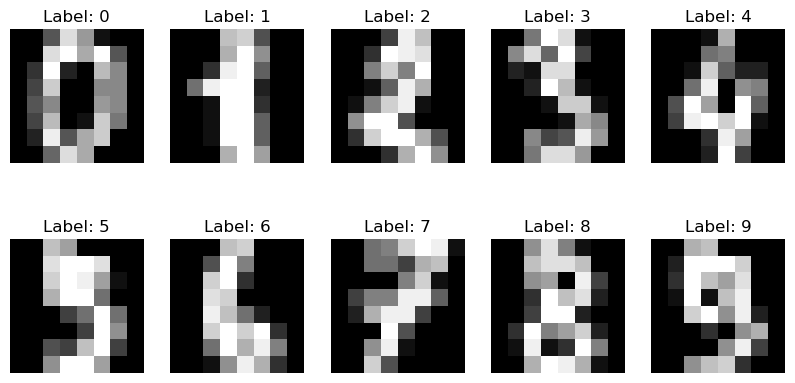

In [5]:
fig, axes = plt.subplots(2,5, figsize=(10,5))

for i, ax in enumerate(axes.flat):
    ax.imshow(digits.images[i], cmap = 'gray')
    ax.set_title(f"Label: {digits.target[i]}")
    ax.axis('off')

plt.show()

## 3. Convert to DataFrame

In [6]:

df = pd.DataFrame(X)
df['label'] = y
df.head()


,0,1,2,3,4,5,6,7,8,9,...,55,56,57,58,59,60,61,62,63,label
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0,0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0,1
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0,2
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0,3
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0,4


## 4. Feature Scaling

In [7]:

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


## 5. Train Test Split

In [8]:

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)


Train size: (1437, 64)
Test size: (360, 64)


## 6. KNN on Full Data

In [9]:

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)
accuracy_full = accuracy_score(y_test, y_pred)

print("KNN Accuracy (Full Features):", accuracy_full)


KNN Accuracy (Full Features): 0.975


## 7. 3D PCA Visualization

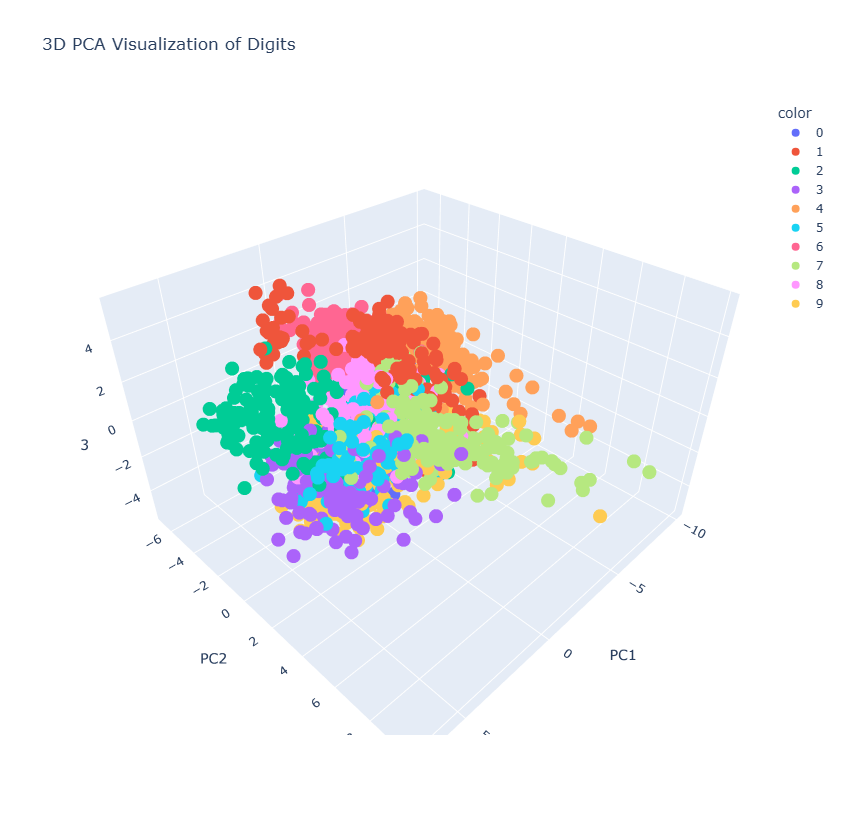

In [10]:

pca_3d = PCA(n_components=3)
X_3d = pca_3d.fit_transform(X_scaled)

df_3d = pd.DataFrame(X_3d, columns=["PC1","PC2","PC3"])
df_3d["label"] = y

fig = px.scatter_3d(df_3d,
                    x="PC1",
                    y="PC2",
                    z="PC3",
                    color=df_3d["label"].astype(str),
                    title="3D PCA Visualization of Digits")

fig.update_layout(
    width=1000,
    height=800
)

fig.show()


## 8. 2D PCA Visualization

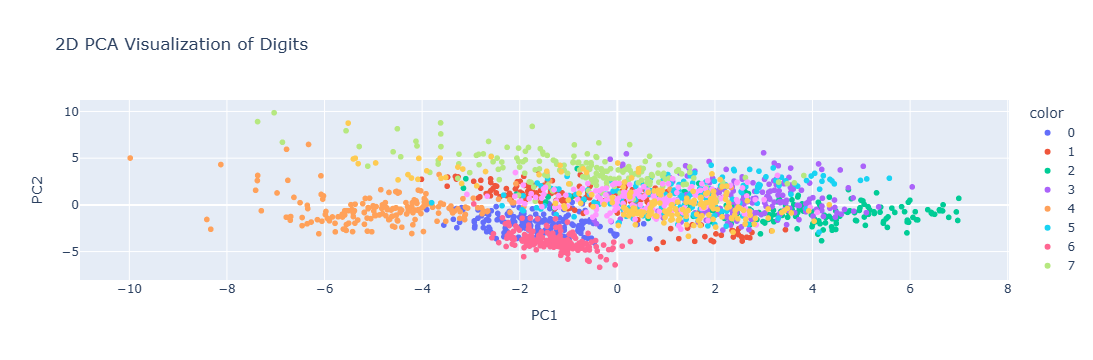

In [11]:

pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X_scaled)

df_2d = pd.DataFrame(X_2d, columns=["PC1","PC2"])
df_2d["label"] = y

fig = px.scatter(df_2d, x="PC1", y="PC2", color=df_2d["label"].astype(str),
                 title="2D PCA Visualization of Digits")

fig.show()


## 9. PCA Transformation

In [12]:

pca = PCA(n_components=20)

X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

print("Original Features:", X_train.shape[1])
print("Reduced Features:", X_train_pca.shape[1])


Original Features: 64
Reduced Features: 20


## 10. KNN using PCA

In [13]:

knn_pca = KNeighborsClassifier(n_neighbors=5)
knn_pca.fit(X_train_pca, y_train)

y_pred_pca = knn_pca.predict(X_test_pca)

accuracy_pca = accuracy_score(y_test, y_pred_pca)
print("KNN Accuracy with PCA:", accuracy_pca)


KNN Accuracy with PCA: 0.9638888888888889


## 11. Accuracy vs Number of PCA Components

In [14]:

results = []

for n in range(1, 65):
    pca = PCA(n_components=n)
    
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)
    
    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(X_train_pca, y_train)
    
    y_pred = knn.predict(X_test_pca)
    acc = accuracy_score(y_test, y_pred)
    
    results.append(acc)
    print('PCs:', n, ' | ', 'acc:', round(acc,2))


PCs: 1  |  acc: 0.32
PCs: 2  |  acc: 0.51
PCs: 3  |  acc: 0.69
PCs: 4  |  acc: 0.85
PCs: 5  |  acc: 0.89
PCs: 6  |  acc: 0.89
PCs: 7  |  acc: 0.92
PCs: 8  |  acc: 0.93
PCs: 9  |  acc: 0.94
PCs: 10  |  acc: 0.94
PCs: 11  |  acc: 0.94
PCs: 12  |  acc: 0.95
PCs: 13  |  acc: 0.94
PCs: 14  |  acc: 0.96
PCs: 15  |  acc: 0.96
PCs: 16  |  acc: 0.96
PCs: 17  |  acc: 0.96
PCs: 18  |  acc: 0.96
PCs: 19  |  acc: 0.96
PCs: 20  |  acc: 0.96
PCs: 21  |  acc: 0.97
PCs: 22  |  acc: 0.96
PCs: 23  |  acc: 0.97
PCs: 24  |  acc: 0.97
PCs: 25  |  acc: 0.97
PCs: 26  |  acc: 0.97
PCs: 27  |  acc: 0.97
PCs: 28  |  acc: 0.97
PCs: 29  |  acc: 0.97
PCs: 30  |  acc: 0.97
PCs: 31  |  acc: 0.97
PCs: 32  |  acc: 0.97
PCs: 33  |  acc: 0.97
PCs: 34  |  acc: 0.97
PCs: 35  |  acc: 0.97
PCs: 36  |  acc: 0.97
PCs: 37  |  acc: 0.97
PCs: 38  |  acc: 0.98
PCs: 39  |  acc: 0.98
PCs: 40  |  acc: 0.97
PCs: 41  |  acc: 0.97
PCs: 42  |  acc: 0.97
PCs: 43  |  acc: 0.97
PCs: 44  |  acc: 0.97
PCs: 45  |  acc: 0.97
PCs: 46  |  acc: 0.

## 12. Plot Accuracy vs Components

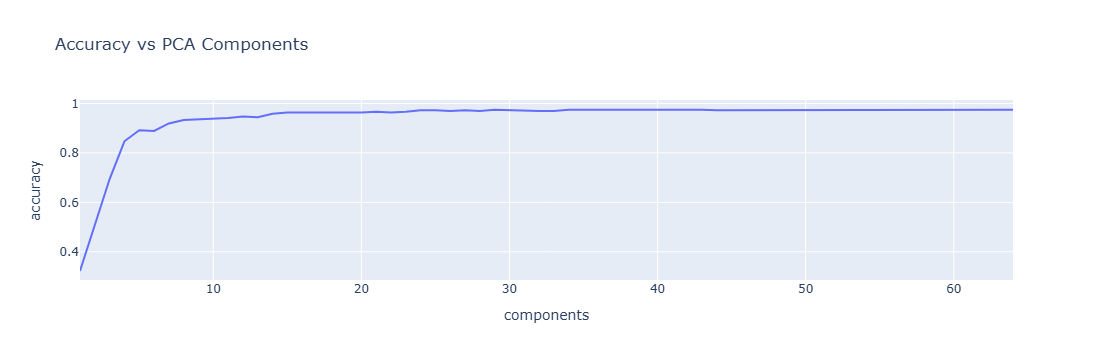

In [15]:

df_results = pd.DataFrame({
    "components": range(1,65),
    "accuracy": results
})

fig = px.line(df_results, x="components", y="accuracy",
              title="Accuracy vs PCA Components")

fig.show()
